**Devoir 1–Compréhension et préparation des données en apprentissage automatique**

**Cours : 8IAR403 – Apprentissage Machine pour les Sciences des Données** 
**Session :Hiver 2026**  

**Nom :DIABATE** 

**Prénom : VAMOUSSA**  

Ce notebook présente les étapes 2 à 4 de la méthodologie de conduite de projets en Machine Learning,appliquées à une étude de cas e-commerce.

**Contexte et objectif du projet**

Ce travail s’inscrit dans le cadre du cours d’apprentissage automatique et vise à mettre en œuvre une chaîne complète de préparation 
des données en respectant les bonnes pratiques de la méthodologie de conduite de projet en machine learning.
L’objectif principal est de préparer un jeu de données clients afin de pouvoir, ultérieurement, entraîner 
un modèle prédictif capable d’estimer la variable cible revenue à partir de caractéristiques clients.

**Q3.1 : Reproduction des étapes (2 à 4)**

**3.1 Reproduire les étapes 2-4 de la méthodologie de conduite de projet  Machine Learning du chapitre 2 vu en classe.** 

Les étapes retenues (selon la démarche du cours) sont :

**Étape 2 – Récupération et compréhension des données**

Cette étape consiste à collecter les données nécessaires au projet et à en acquérir une première compréhension globale.
Elle comprend notamment :

-Le chargement des différentes sources de données (fichiers CSV).

-L’identification des variables disponibles (numériques, catégorielles, binaires).

-La vérification de la structure des données : nombre d’observations, nombre de variables, types de données.

Une première exploration permettant de détecter :

-la présence de valeurs manquantes,

-d’éventuelles incohérences,

-ou des erreurs de format.

Objectif principal est de s’assurer que les données sont exploitables et comprendre leur contenu avant toute transformation ou modélisation.
    

**Étape 3 – Analyse exploratoire des données (EDA)**

L’analyse exploratoire vise à mieux comprendre le comportement statistique des données et les relations entre les variables.
Cette étape inclut :

-L’analyse descriptive des variables numériques (moyenne, médiane, dispersion, quartiles).

-La visualisation des distributions (histogrammes, boxplots).

-L’étude des variables catégorielles (répartition des modalités).

-L’analyse des corrélations entre les variables explicatives et la variable cible.

-La détection visuelle des valeurs aberrantes (outliers).

Objectif principal est d'identifier les variables importantes, comprendre leurs relations avec la cible et repérer
les problèmes à corriger lors de la préparation des données.


**Étape 4 – Préparation des données**

Cette étape transforme les données brutes en données propres et compatibles avec les algorithmes de Machine Learning.
Elle comprend généralement :

-La séparation du jeu de données en ensemble d’entraînement et ensemble de test, afin d’éviter toute fuite d’information.

-Le traitement des valeurs manquantes (imputation par moyenne, médiane, etc.).

-La gestion des valeurs aberrantes (suppression ou bornage).

-La transformation des variables catégorielles (encodage One-Hot, label encoding).

-L’enrichissement éventuel des données à l’aide de sources externes.

-L’utilisation de pipelines pour garantir la reproductibilité des transformations.

Objectif principal est de produire un jeu de données final cohérent, numérique, sans valeurs manquantes, prêt pour l’entraînement du modèle.

**Chargement des modules**

In [24]:
#Chargement des modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector

**Étape 2 – Récupération et compréhension des données.**

**Question 3.2  : Nettoyage des données du dataset(Customer.csv).**

Dans cette étape, je charges les jeux de données fournis(Customer.csv) et vérifions 
sa structure afin de m’assurer qu’il est exploitables pour les étapes suivantes.

**Q3.2.1 : Localisation des données manquantes**

**Chargement du dataset principal(Customer.csv)**

In [25]:
#Chargement du dataset principal(Customer.csv)

data_client = pd.read_csv('Customer.csv')
data_client

,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
0,41.0,6.0,28.0,Fem,False,4.0,China,113
1,34.0,4.0,15.5,Fem,True,2.0,China,36
2,38.0,5.0,?,Fem,False,7.0,China,111
3,20.0,1.0,44.0,Fem,False,2.0,China,71
4,39.0,10.0,10.0,Fem,True,4.0,China,80
...,...,...,...,...,...,...,...,...
9995,49.0,8.0,44.0,Masc,False,4.0,Taiwan,254
9996,32.0,5.0,42.0,Masc,False,1.0,Taiwan,82
9997,47.0,8.0,15.5,Fem,True,3.0,Taiwan,117
9998,42.0,7.0,42.0,Fem,False,2.0,Taiwan,70


In [26]:
data_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               10000 non-null  float64
 1   pages             10000 non-null  float64
 2   first_item_prize  10000 non-null  object 
 3   gender            10000 non-null  object 
 4   ReBuy             10000 non-null  bool   
 5   News_click        10000 non-null  float64
 6   country           10000 non-null  object 
 7   revenue           10000 non-null  object 
dtypes: bool(1), float64(3), object(4)
memory usage: 556.8+ KB


**Analyse**

je vois la présence de valeurs manquantes dans le jeu de données.
Ces valeurs apparaissent principalement dans la variable first_item_prize et marginalement dans revenue, 
tandis que les autres variables semblent majoritairement complètes.

La distribution des valeurs manquantes est limitée et non systématique, ce qui suggère qu’elles ne sont pas liées à 
un sous-groupe particulier de clients.Ce constat justifie l’utilisation d’une méthode d’imputation plutôt qu’une suppression des observations, 
afin de conserver un maximum d’information pour l’apprentissage du modèle.

**Q3.2.1 Nettoyage données manquantes**

**Remplacement des valeurs inconnues (? ) par NAN, ainsi on peut directement exploiter Imputer.**

In [27]:
#Remplacement des valeurs inconnues (? )
#par NAN, ainsi on peut directement exploiter Imputer.
data_client = pd.read_csv('Customer.csv', na_values=['?', 'unknown'])
data_client

,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
0,41.0,6.0,28.0,Fem,False,4.0,China,113.0
1,34.0,4.0,15.5,Fem,True,2.0,China,36.0
2,38.0,5.0,NaN,Fem,False,7.0,China,111.0
3,20.0,1.0,44.0,Fem,False,2.0,China,71.0
4,39.0,10.0,10.0,Fem,True,4.0,China,80.0
...,...,...,...,...,...,...,...,...
9995,49.0,8.0,44.0,Masc,False,4.0,Taiwan,254.0
9996,32.0,5.0,42.0,Masc,False,1.0,Taiwan,82.0
9997,47.0,8.0,15.5,Fem,True,3.0,Taiwan,117.0
9998,42.0,7.0,42.0,Fem,False,2.0,Taiwan,70.0


**comprehension des données**

**Audit des dimensions de mon dataset**

shape renvoie un tuple (lignes, colonnes). 
Cela permet de vérifier immédiatement :
1. Le volume de données (nombre de clients).
2. Le nombre de variables (features) disponibles au départ.

In [28]:
#Audit des dimensions de mon dataset
data_client.shape

(10000, 8)

**Aperçu des données brutes**

.head() affiche par défaut les 5 premières lignes de mon DataFrame.
Cette étape est cruciale pour :
 1. Valider visuellement que les colonnes ont été correctement nommées.
 2. Identifier le type de contenu (ex: texte pour les pays, nombres pour l'âge).
 3. Repérer d'éventuelles anomalies flagrantes dès l'ouverture du fichier.

In [29]:
#Aperçu des données brutes

data_client.head()

,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
0,41.0,6.0,28.0,Fem,False,4.0,China,113.0
1,34.0,4.0,15.5,Fem,True,2.0,China,36.0
2,38.0,5.0,NaN,Fem,False,7.0,China,111.0
3,20.0,1.0,44.0,Fem,False,2.0,China,71.0
4,39.0,10.0,10.0,Fem,True,4.0,China,80.0


**Diagnostic technique des types et des valeurs manquantes**

.info() fournit un résumé crucial :
1. Le nombre total d'entrées (lignes).
2. Le type de données de chaque colonne (float64, int64, object).
3. Le décompte des valeurs "Non-Null". 
Si ce nombre est inférieur au total d'entrées, cela confirme la présence de données manquantes.

In [30]:
#Diagnostic technique des types et des valeurs manquantes
data_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               10000 non-null  float64
 1   pages             10000 non-null  float64
 2   first_item_prize  9997 non-null   float64
 3   gender            10000 non-null  object 
 4   ReBuy             10000 non-null  bool   
 5   News_click        10000 non-null  float64
 6   country           10000 non-null  object 
 7   revenue           9996 non-null   float64
dtypes: bool(1), float64(5), object(2)
memory usage: 556.8+ KB


**Analyse statistique descriptive**

.describe() génère un tableau statistique pour les colonnes numériques.
C'est ici que je détecte les premiers signes de bruit ou d'anomalies :
1. mean vs 50% (médiane) : Si elles sont très éloignées, la distribution est asymétrique.
2. std (écart-type) : Indique la dispersion des données autour de la moyenne.
3. min/max : Permet de repérer des valeurs aberrantes (ex: un âge négatif ou de 200 ans).
4. Quartiles (25%, 50%, 75%) : Essentiels pour comprendre la répartition de ton 'revenue'.

In [31]:
#Analyse statistique descriptive
data_client.describe()

,age,pages,first_item_prize,News_click,revenue
count,10000.000000,10000.000000,9997.000000,10000.000000,9996.000000
mean,37.431400,5.995000,40.431730,4.412000,122.812625
std,9.490474,2.438559,27.556289,2.418231,86.750910
min,18.000000,1.000000,10.000000,0.000000,1.000000
25%,31.000000,5.000000,22.000000,3.000000,59.000000
50%,37.000000,6.000000,42.000000,4.000000,100.000000
75%,43.000000,7.000000,44.000000,6.000000,164.000000
max,79.000000,14.000000,117.000000,10.000000,995.000000


**Inventaire des données manquantes**

.isnull() génère un tableau de True/False (True si la donnée manque).
.sum() additionne ces True par colonne pour donner le total de valeurs manquantes.
c'est l'étape qui justifie techniquement la mise en place d'une stratégie d'imputation (remplacement des vides par la médiane ou le mode).

In [32]:
#Inventaire des données manquantes
data_client.isnull().sum()

age                 0
pages               0
first_item_prize    3
gender              0
ReBuy               0
News_click          0
country             0
revenue             4
dtype: int64

**Découvrir et visualiser les données**

**Exploration visuelle de Customer.csv**

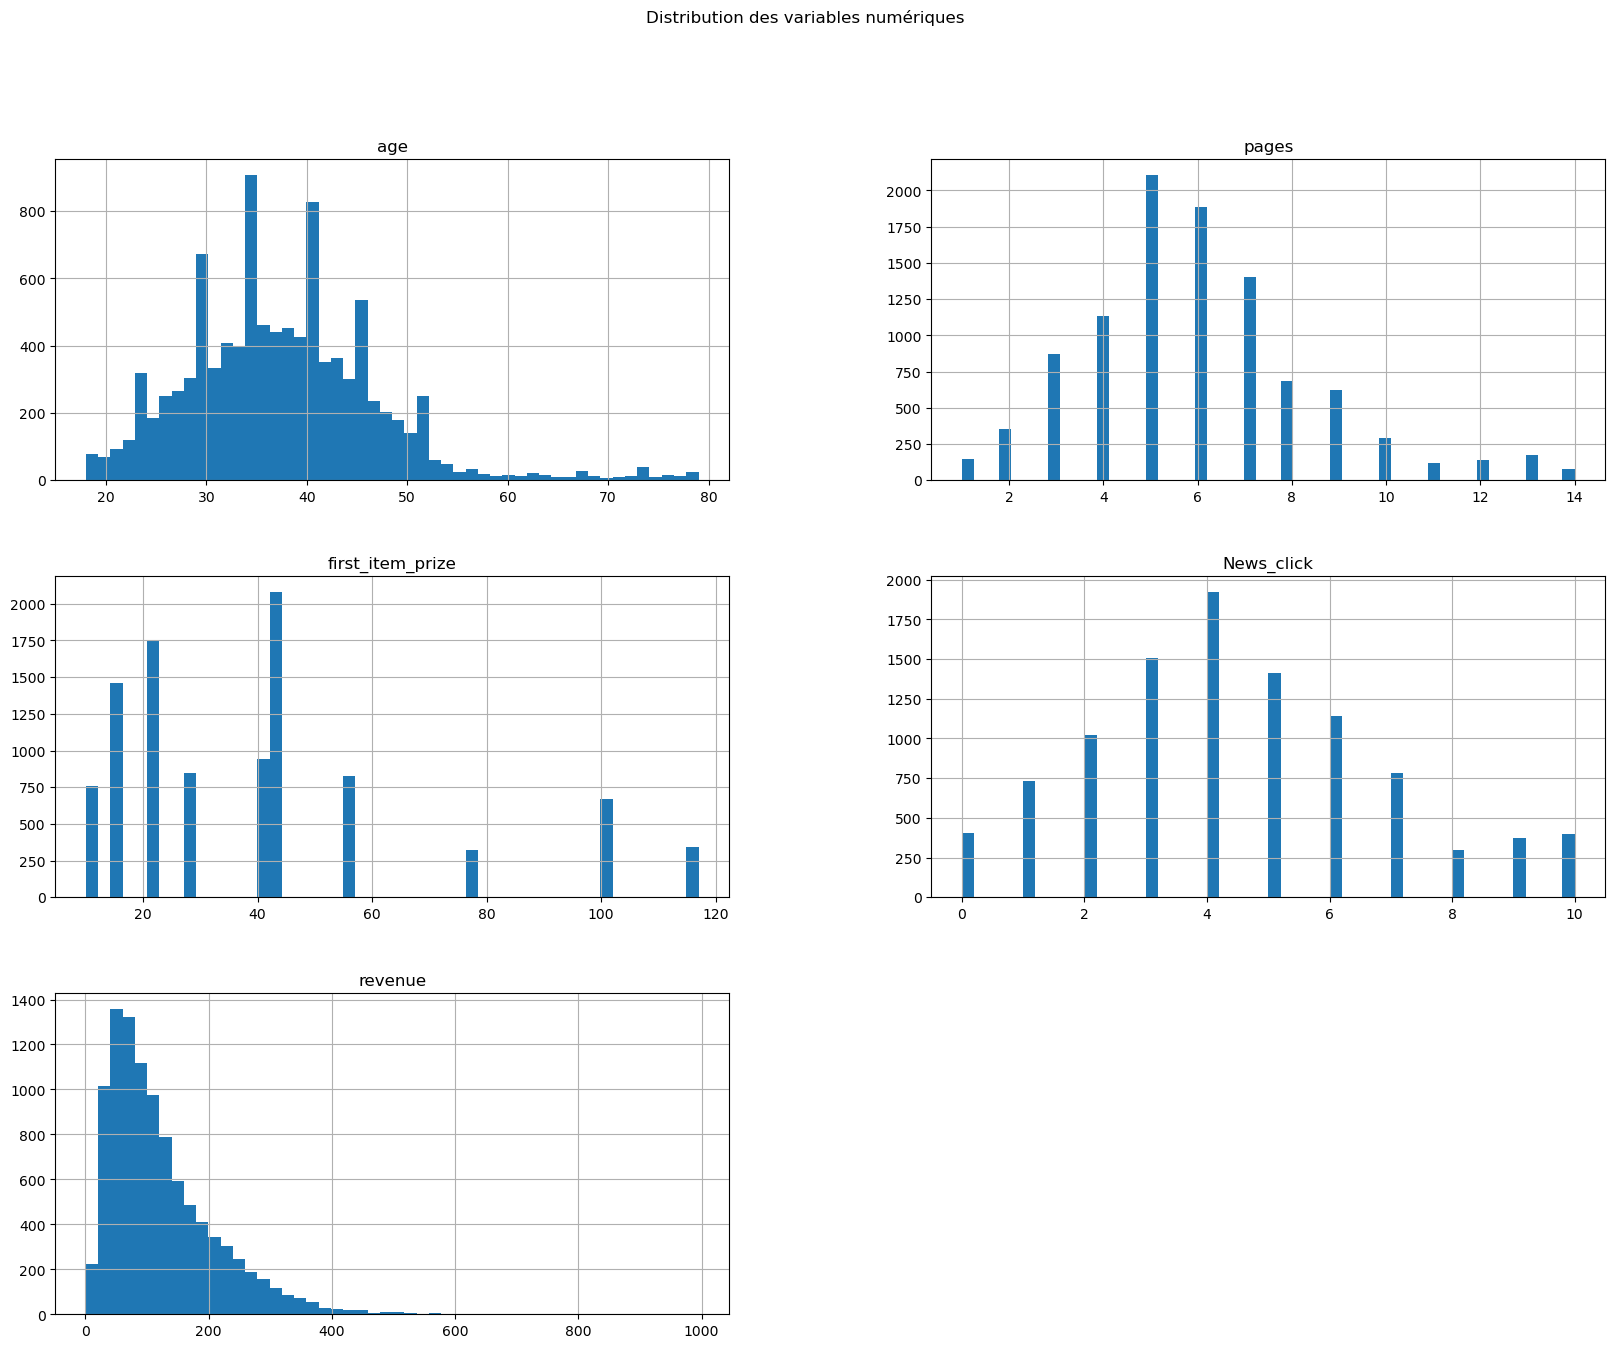

In [33]:
#Exploration visuelle de Customer.csv

#J'ai générée un histogramme pour chaque variable numérique du dataset.
# L'utilisation de 50 bins permet d'avoir une résolution fine pour détecter les distributions (ex: loi normale, asymétrie).
# figsize=(20,15) assure que les graphiques restent lisibles malgré leur nombre.

data_client.hist(bins=50, figsize=(20,15))

# J'ajout d'un titre général pour identifier le but de la visualisation
plt.suptitle("Distribution des variables numériques")

# Affichage des graphiques pour analyser les tendances et identifier d'éventuels outliers ou erreurs de saisie
plt.show()

**Analyse**

Les histogrammes mettent en évidence des distributions asymétriques pour certaines
variables numériques, notamment la variable *revenue*, qui présente une forte asymétrie à droite et des valeurs extrêmes potentielles.

**Préparer les données (nettoyage + pipeline + enrichissement)**

**Analyse de la complétude des données**

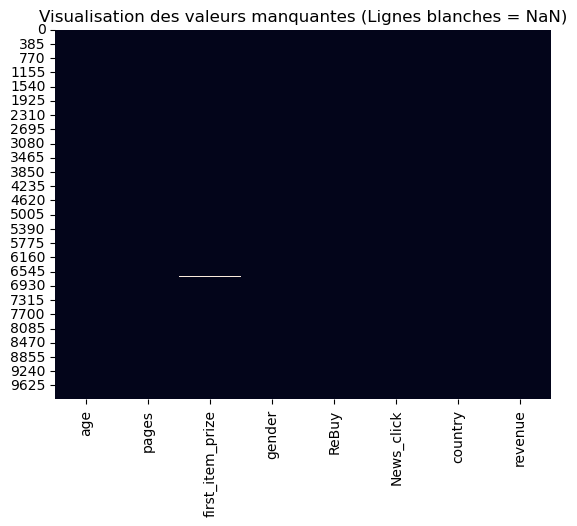

In [34]:
#Analyse de la complétude des données

# Utilisation d'une "heatmap" (carte de chaleur) pour visualiser les données manquantes.
# Chaque trait blanc représenterait une valeur nulle (NaN) dans le dataset.
# cbar=False permet de supprimer la barre de légende pour une visualisation plus épurée.
sns.heatmap(data_client.isnull(), cbar=False)

# Identification rapide des colonnes critiques qui nécessiteront une imputation (SimpleImputer)
plt.title("Visualisation des valeurs manquantes (Lignes blanches = NaN)")

# Affichage du graphique
plt.show()

**Analyse**

La visualisation des valeurs manquantes montre la présence de données absentes
dans certaines colonnes, ce qui va justifier la mise en place d’un traitement spécifique
lors de l’étape de préparation des données.

**Étape 3 – Analyse exploratoire des données (EDA)**

**comprehension et visualiser les données d'entraînement train_set**

In [35]:
#Création des jeux de données

# Division du dataset original en deux parties : 
# 1. train_set (80%) : servira à l'entraînement du modèle.
# 2. test_set (20%) : servira d'ensemble "aveugle" pour évaluer la performance finale du modèle.
from sklearn.model_selection import train_test_split

# random_state=42 : fixe la graine de l'algorithme de mélange. 
# Cela garantit que la division est reproductible (on obtient toujours les mêmes lignes à chaque exécution).
train_set, test_set = train_test_split(data_client, test_size=0.2, random_state=42)

# Vérification des dimensions pour s'assurer du bon découpage
print(f"Taille de l'entraînement : {len(train_set)} | Taille du test : {len(test_set)}")

Taille de l'entraînement : 8000 | Taille du test : 2000


**Analyse**

Conformément aux bonnes pratiques en apprentissage automatique, le jeu de données
est séparé en un ensemble d’entraînement (80 %) et un ensemble de test (20 %).
Toutes les étapes de préparation (valeurs manquantes, valeurs aberrantes et enrichissement)
sont réalisées **en apprenant les paramètres uniquement sur `train_set`**.
Ensuite, ces transformations sont appliquées à `test_set` **sans ré-apprentissage**.

In [36]:
# Je travaille sur des copies pour éviter de modifier l'original
train_set = train_set.copy()
test_set  = test_set.copy()

In [37]:
train_set.shape

(8000, 8)

In [38]:
train_set.head()

,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
9254,36.0,6.0,10.0,Masc,False,3.0,Ghana,14.0
1561,36.0,6.0,22.0,Masc,True,4.0,Bangladesh,66.0
1670,38.0,3.0,44.0,Fem,False,3.0,Russia,74.0
6087,36.0,4.0,15.5,Masc,False,10.0,Argentina,116.0
6669,40.0,4.0,15.5,Fem,False,7.0,Sudan,36.0


In [39]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               8000 non-null   float64
 1   pages             8000 non-null   float64
 2   first_item_prize  7997 non-null   float64
 3   gender            8000 non-null   object 
 4   ReBuy             8000 non-null   bool   
 5   News_click        8000 non-null   float64
 6   country           8000 non-null   object 
 7   revenue           7997 non-null   float64
dtypes: bool(1), float64(5), object(2)
memory usage: 507.8+ KB


In [40]:
train_set.describe(include=np.number)

,age,pages,first_item_prize,News_click,revenue
count,8000.000000,8000.000000,7997.000000,8000.000000,7997.000000
mean,37.391750,6.009500,40.285044,4.403625,122.725272
std,9.480534,2.439806,27.625504,2.427179,86.444314
min,18.000000,1.000000,10.000000,0.000000,3.000000
25%,31.000000,5.000000,22.000000,3.000000,60.000000
50%,37.000000,6.000000,42.000000,4.000000,100.000000
75%,43.000000,7.000000,44.000000,6.000000,164.000000
max,79.000000,14.000000,117.000000,10.000000,995.000000


**Isolation des variables numériques**

In [41]:
#Isolation des variables numériques

# je Crée un sous-ensemble 'data_num' contenant uniquement les colonnes quantitatives.
# Je supprime (drop) les variables qualitatives/catégorielles comme le genre et le pays,
# ainsi que la variable binaire "ReBuy" pour faciliter l'analyse statistique.
data_num = train_set.drop(["gender", "ReBuy", "country"], axis=1)

# Affichage des premières lignes pour valider que seules les colonnes numériques 
# (ex: age, pages, revenue, first_item_prize) sont conservées.
data_num

,age,pages,first_item_prize,News_click,revenue
9254,36.0,6.0,10.0,3.0,14.0
1561,36.0,6.0,22.0,4.0,66.0
1670,38.0,3.0,44.0,3.0,74.0
6087,36.0,4.0,15.5,10.0,116.0
6669,40.0,4.0,15.5,7.0,36.0
...,...,...,...,...,...
5734,48.0,7.0,44.0,6.0,167.0
5191,25.0,10.0,22.0,2.0,33.0
5390,34.0,3.0,28.0,6.0,127.0
860,65.0,7.0,10.0,8.0,111.0


**Visualisation de la distribution des donnees de train_set**

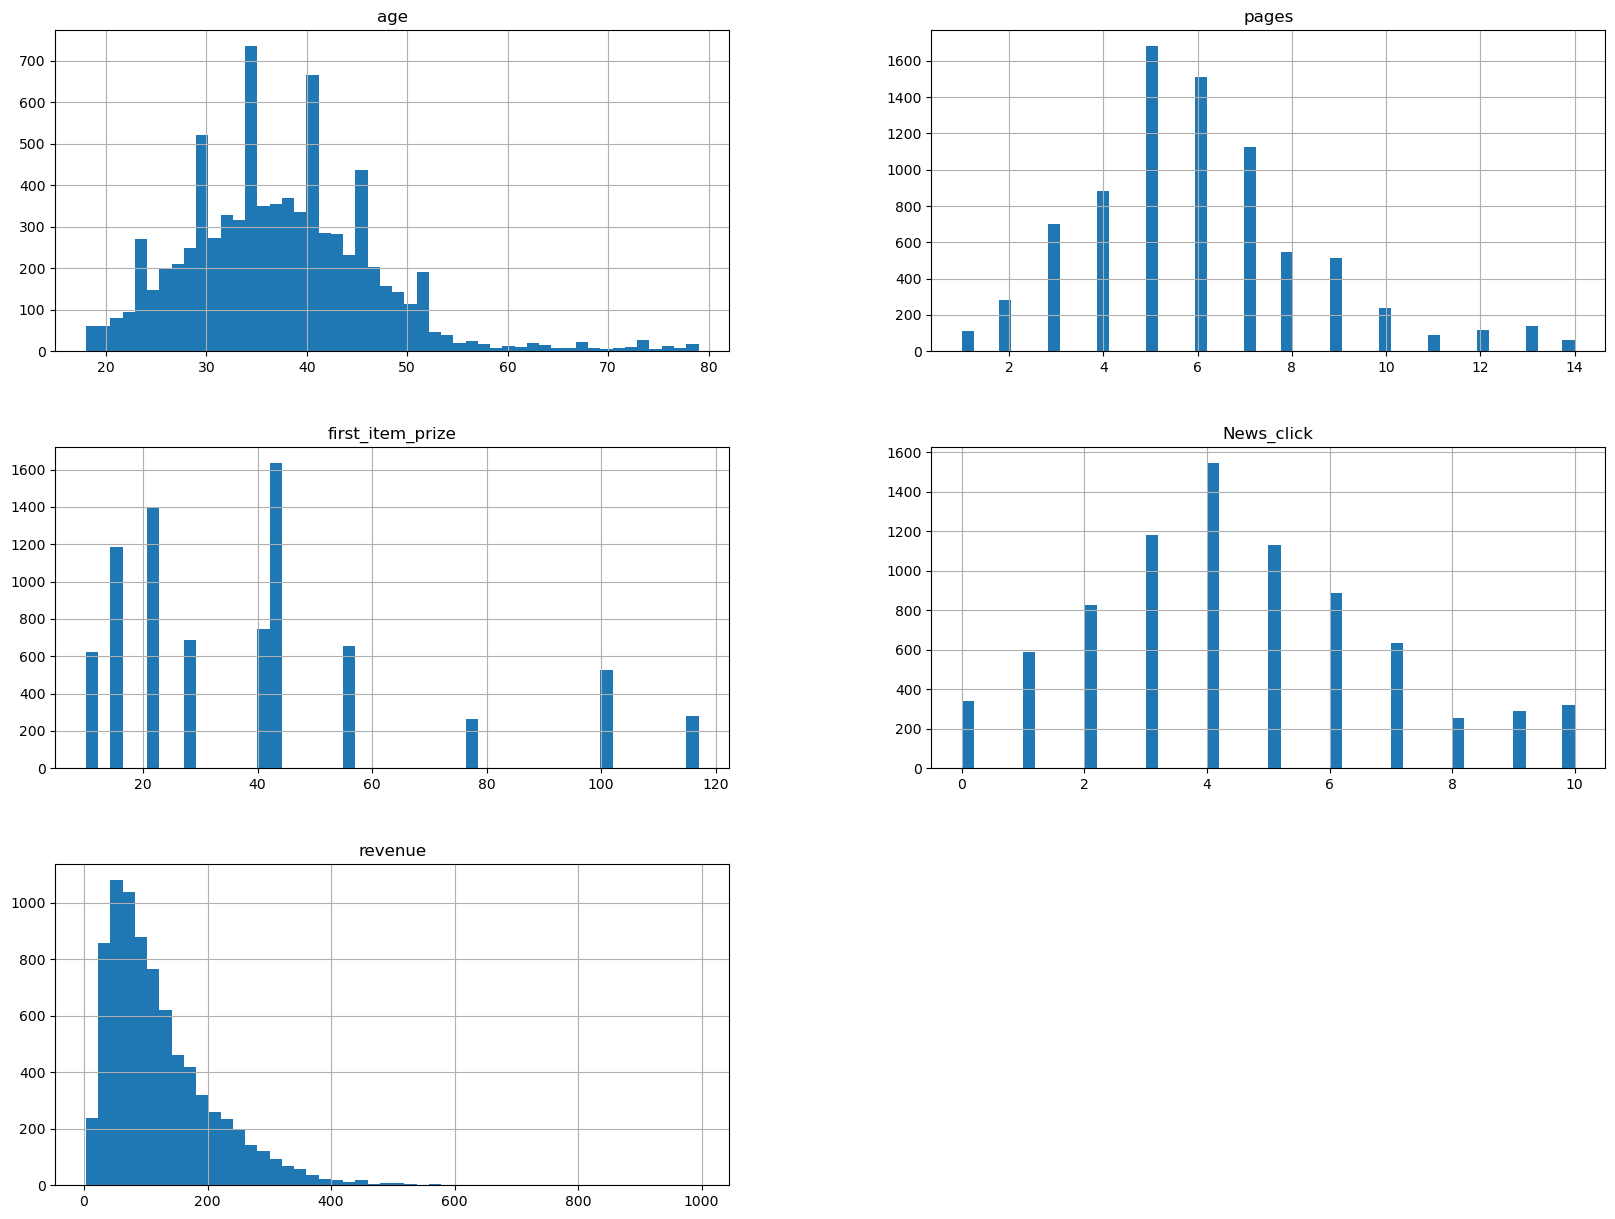

In [42]:
#Visualisation de la distribution des donnees de train_set

# La commande magique %matplotlib inline permet d'afficher les graphiques 
# directement dans l'interface du Notebook Jupyter.
%matplotlib inline
import matplotlib.pyplot as plt

# Génération des histogrammes pour toutes les variables numériques du dataset 'data_num'.
# bins=50 : définit le nombre de barres. Un nombre élevé permet de mieux détecter 
# les distributions asymétriques ou la présence d'outliers isolés.
# figsize=(20,15) : ajuste la taille de la figure pour que chaque graphique soit lisible.
data_num.hist(bins=50, figsize=(20,15))

# Affichage final des graphiques.
plt.show()

**Analyse exploratoire**

Cette étape permet d’identifier visuellement les variables nécessitant un traitement (imputation ou écrêtage).

**Analyse de la répartition des catégories (Variable 'gender')**

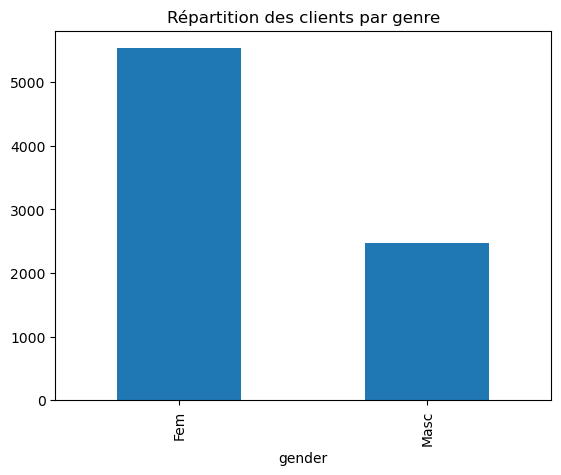

In [43]:
#Analyse de la répartition des catégories (Variable 'gender')

# .value_counts() : Compte le nombre d'occurrences pour chaque catégorie (ex: Male, Female).
# .plot.bar() : Génère un diagramme en barres pour visualiser l'équilibre des données.
train_set['gender'].value_counts().plot.bar()

# J'ajout un titre pour identifier le graphique
plt.title("Répartition des clients par genre")

# J'affichage pour vérifier s'il existe un déséquilibre important qui pourrait biaiser le modèle
plt.show()

**Répartition des clients par genre**

Le graphique montre une distribution déséquilibrée entre les genres.
Les clientes de genre féminin (Fem) sont majoritaires par rapport aux clients masculins (Masc).
Ce déséquilibre devra être pris en compte lors de la modélisation, car il peut influencer
les performances du modèle ou introduire un biais si la variable *gender* est utilisée comme variable explicative.

**Analyse des corrélations**

In [44]:
#Analyse des corrélations

# Calcul de la matrice de corrélation de Pearson entre toutes les variables numériques.
# Ce coefficient (entre -1 et 1) mesure la force et la direction du lien linéaire 
# entre deux variables.
corr_matrix = data_num.corr()

# Affichage de la matrice pour identifier les variables les plus corrélées au 'revenue'.
# Une valeur proche de 1 indique une forte corrélation positive, tandis qu'une valeur 
# proche de 0 indique une absence de lien linéaire.
corr_matrix

,age,pages,first_item_prize,News_click,revenue
age,1.000000,0.010551,0.015835,-0.005927,0.022159
pages,0.010551,1.000000,-0.016496,-0.012322,-0.010377
first_item_prize,0.015835,-0.016496,1.000000,0.005389,0.367441
News_click,-0.005927,-0.012322,0.005389,1.000000,0.374412
revenue,0.022159,-0.010377,0.367441,0.374412,1.000000


**Analyse de la matrice de corrélation**

La matrice de corrélation montre que les variables *first_item_prize* et *News_click*
présentent les corrélations les plus élevées avec la variable cible *revenue*(respectivement ≈ 0.36 et ≈ 0.37).
Cela indique que le prix du premier article acheté ainsi que le nombre de clics
sur les newsletters sont des facteurs potentiellement explicatifs du revenu généré par un client.
Les autres variables (*age* et *pages*) présentent des corrélations très faibles avec *revenue*, suggérant un impact limité pris isolément.

**Zoom sur la variable cible qui est "revenue"**

In [45]:
#Zoom sur la variable cible qui est "revenue"

# On extrait spécifiquement la colonne 'revenue' de la matrice de corrélation.
# .sort_values(ascending=False) : Trie les résultats du plus corrélé au moins corrélé.
# Cela permet d'identifier immédiatement quels facteurs (ex: âge, nombre de pages) 
# ont la plus grande influence positive ou négative sur les ventes.
corr_matrix["revenue"].sort_values(ascending=False)

revenue             1.000000
News_click          0.374412
first_item_prize    0.367441
age                 0.022159
pages              -0.010377
Name: revenue, dtype: float64

**Interprétation**

Les variables *News_click* et *first_item_prize* présentent les corrélations positives
les plus élevées avec la variable cible *revenue*.  
Elles seront donc particulièrement pertinentes pour la phase de modélisation.

**3.2.2 Remplacement des données aberrantes (extrêmes, outliers)**

**Q3.2.2 : Localisation de données aberrantes**

**Détection des outliers pour des variables numériques**

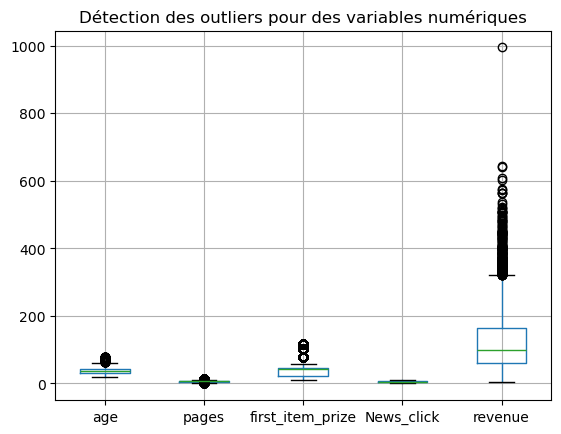

In [46]:
#Détection visuelle des valeurs aberrantes (Outliers)

# Utilisation d'un boxplot pour les variables 'age', 'pages', 'first_item_prize', 'News_click', 'revenue'.
# La boîte représente l'intervalle interquartile (IQR = Q3 - Q1).
# Les points situés au-delà des "moustaches" sont considérés statistiquement comme des outliers.
train_set[['age', 'pages', 'first_item_prize', 'News_click', 'revenue']].boxplot()
plt.title("Détection des outliers pour des variables numériques")
plt.show()

Le boxplot global met en évidence la présence de valeurs aberrantes pour plusieurs variables,
en particulier pour la variable *revenue*, qui présente une forte dispersion et de nombreuses
valeurs extrêmes supérieures. Cette forte variabilité explique l’écrasement visuel des autres
variables sur le graphique commun, justifiant l’utilisation complémentaire de boxplots
individuels par variable pour une analyse plus fine.

**Visualisation des données aberrantes par boîte à moustaches**

Afin de compléter l’analyse, des boxplots individuels ont été réalisés pour chaque
variable numérique. Cette représentation permet d’identifier plus précisément la
présence et l’ampleur des valeurs aberrantes, qui peuvent être masquées dans une
visualisation globale en raison des différences d’échelle entre les variables.

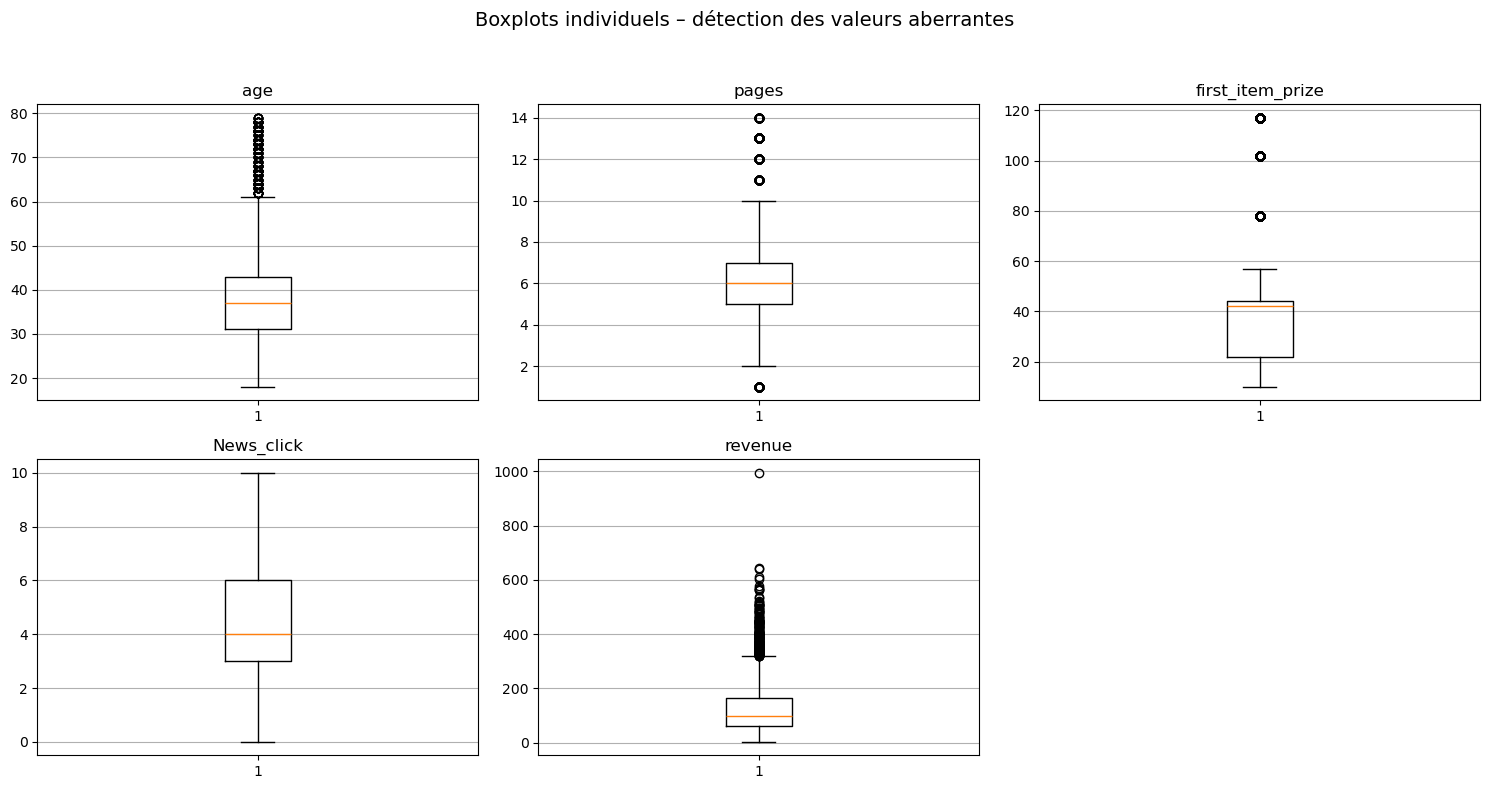

In [47]:
import matplotlib.pyplot as plt

num_cols = ['age', 'pages', 'first_item_prize', 'News_click', 'revenue']

plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(train_set[col].dropna(), vert=True)
    plt.title(col)
    plt.grid(axis='y')

plt.suptitle("Boxplots individuels – détection des valeurs aberrantes", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Les boxplots individuels mettent en évidence une forte hétérogénéité des distributions
numériques ainsi qu’une présence significative de valeurs aberrantes, en particulier
pour la variable *revenue*. Ces valeurs extrêmes semblent cohérentes d’un point de vue
métier et traduisent des comportements clients spécifiques(exemple des clients qui font des achats exorbitant). Aucun retrait automatique
n’est appliqué à ce stade, mais cette structure des données devra être prise en compte
lors des étapes de normalisation et de modélisation.

**Séparation des variables prédictives (Features) et de la cible (Target)**

In [48]:
#Séparation des variables prédictives (Features) et de la cible (Target)

# X_train : contient toutes les données d'entrée sauf la colonne 'revenue'.
# C'est l'ensemble des caractéristiques que le modèle va analyser.
X_train = train_set.drop(["revenue"], axis=1)
X_train 
# y_train : contient uniquement la colonne 'revenue'.
# C'est la variable cible (la réponse) que le modèle doit apprendre à prédire.
y_train = train_set["revenue"]
y_train
# Cette séparation est indispensable pour la phase d'entraînement (fit) 
# afin que le modèle ne connaisse pas déjà la réponse pendant son apprentissage.

9254     14.0
1561     66.0
1670     74.0
6087    116.0
6669     36.0
        ...  
5734    167.0
5191     33.0
5390    127.0
860     111.0
7270     45.0
Name: revenue, Length: 8000, dtype: float64

**Gestion des valeurs manquantes pour les variables numériques**

In [49]:
#Gestion des valeurs manquantes pour les variables numériques

# Initialisation du SimpleImputer avec la stratégie "median".
# j'utilise la médiane plutôt que la moyenne car elle est moins sensible 
# aux valeurs aberrantes (outliers) identifiées précédemment.
imputer = SimpleImputer(strategy="median")

# J'ajuste l'imputer et transforme les données.
# 1. fit : Calcule la médiane pour chaque colonne de data_num.
# 2. transform : Remplace les NaN (valeurs manquantes) par la médiane calculée.
X = imputer.fit_transform(data_num)
X
# Le résultat 'X' est un tableau Numpy que nous pourrons reconvertir en DataFrame si besoin.

array([[ 36. ,   6. ,  10. ,   3. ,  14. ],
       [ 36. ,   6. ,  22. ,   4. ,  66. ],
       [ 38. ,   3. ,  44. ,   3. ,  74. ],
       ...,
       [ 34. ,   3. ,  28. ,   6. , 127. ],
       [ 65. ,   7. ,  10. ,   8. , 111. ],
       [ 49. ,   4. ,  15.5,   3. ,  45. ]])

**Q3.2.2 : Nettoyage données aberrantes (Outliers)**

Bien que plusieurs variables numériques présentent des valeurs élevées, seul l’âge
fera l’objet d’un traitement des valeurs aberrantes supérieures.En effet,
l’âge est une variable naturellement bornée pour laquelle certaines valeurs
extrêmes observées peuvent être considérées comme peu représentatives de la
population étudiée et susceptibles d’introduire un biais dans le modèle(ex:bizarre de voir quelques âgé de 200 ans).

À l’inverse, les autres variables numériques (pages, News_click, first_item_prize)
représentent des comportements ou des grandeurs économiques pour lesquelles les
valeurs élevées sont plausibles et informatives. De plus, la variable revenue
étant la variable cible, elle n’a pas été modifiée afin de préserver la structure
réelle des revenus observés.

Le traitement des valeurs aberrantes a donc été volontairement limité à la
variable age, dans une logique de préparation des données guidée par le sens
métier et l’impact sur le modèle prédictif.

**Détection des outliers pour la variables âge**

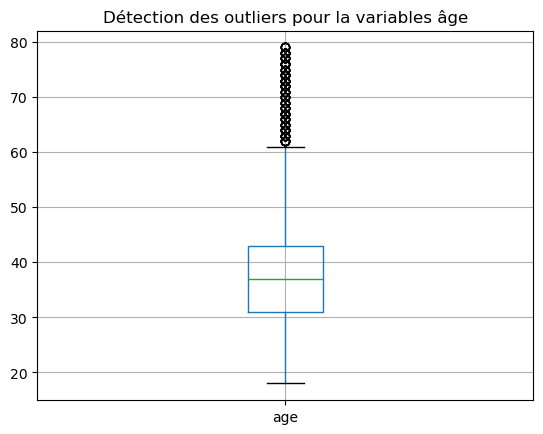

In [50]:
#Détection visuelle des valeurs aberrantes (Outliers)

# Utilisation d'un boxplot pour la variable 'age'.
# La boîte représente l'intervalle interquartile (IQR = Q3 - Q1).
# Les points situés au-delà des "moustaches" sont considérés statistiquement comme des outliers.
train_set[['age']].boxplot()
plt.title("Détection des outliers pour la variables âge")
plt.show()

Bien que les valeurs élevées de la variable age (ex. 70–77 ans) soient réalistes d’un point de vue métier, elles apparaissent comme statistiquement aberrantes selon la méthode de l’intervalle interquartile (IQR).
Afin de limiter leur influence sur l’apprentissage du modèle sans supprimer d’observations, un écrêtage (clipping) basé sur les seuils de Tukey va être appliqué exclusivement à cette variable.

**traitement des valeurs aberrantes (Outliers)**

In [51]:
#Fonction de traitement des valeurs aberrantes (Outliers)

def nettoyageOutliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cette fonction réalise l'écrêtage (clipping) des données numériques.
    Elle utilise la méthode des moustaches de Tukey pour identifier les seuils critiques.
    """
    cols = df.columns
    
    # Calcul des quartiles : Q1 (25%) et Q3 (75%)
    Q25 = df[cols].quantile(0.25) 
    Q75 = df[cols].quantile(0.75)
    
    # Écart interquartile (IQR) : mesure la dispersion statistique des données
    IQR = Q75 - Q25
    
    # Définition des seuils de détection standards (1.5 fois l'IQR)
    SeuilMin = (Q25 - 1.5 * IQR)
    SeuilMax = (Q75 + 1.5 * IQR)
    
    # La fonction .clip() remplace les valeurs au-delà des seuils par la valeur du seuil lui-même.
    # Contrairement à une suppression, cela permet de conserver toutes les lignes du dataset
    # tout en réduisant l'impact des valeurs extrêmes sur le modèle.
    nouv_df = df[cols].clip(lower=SeuilMin, upper=SeuilMax, axis=1)
    
    return nouv_df

**Vérification du traitement des outliers**

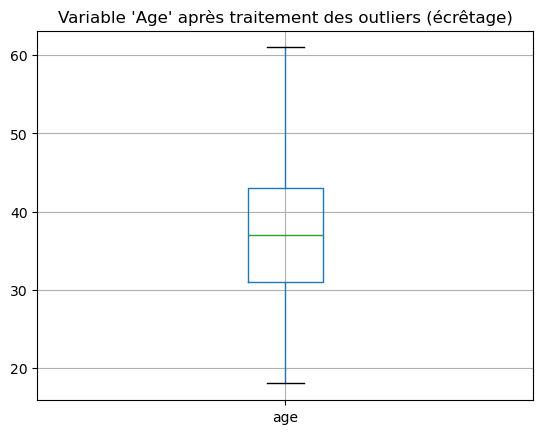

In [52]:
#Vérification du traitement des outliers

# 1. On transforme le tableau Numpy 'X' (issu de l'imputation) en DataFrame.
# Il est nécessaire de remettre les noms de colonnes pour que la fonction 
# 'nettoyageOutliers' puisse identifier les variables.
df_propre = pd.DataFrame(X, columns=data_num.columns)

# 2. Application de la fonction de nettoyage (écrêtage/clipping)
resultat = nettoyageOutliers(df_propre)

# 3. Visualisation finale de la variable 'age' pour confirmer la correction.
# Sur ce nouveau graphique, les points isolés au-dessus de la moustache 
# supérieure devraient avoir disparu, car ils ont été ramenés au seuil maximum.
resultat[['age']].boxplot()

# Ajout d'un titre pour marquer la réussite du traitement
plt.title("Variable 'Age' après traitement des outliers (écrêtage)")
plt.show()

**Q3.2.2 Utilisation d’un pipeline**

In [53]:
#Adaptateur pour le Pipeline

def bornage(data):
    """
    Cette fonction sert d'interface entre Scikit-Learn et notre logique métier.
    Le Pipeline de Scikit-Learn manipule les tableaux Numpy (sans noms de colonnes).
    Je force donc la conversion en DataFrame pour que 'nettoyageOutliers' puisse 
    effectuer ses calculs statistiques (quartiles).
    """
    # Conversion explicite en DataFrame et appel de la fonction d'écrêtage
    return nettoyageOutliers(pd.DataFrame(data))

**Étape 4 – Préparation des données**

**Q3.3 Enrichissement des données:Nettoyage des deux datasets (PIB,Population)**

**Q3.3 Enrichissement des données : Jointure paramétrable**

**a) Nettoyons les deux dataset (CountryGDP et CountryPopulation)**

**chargement des dataset(pib/population)**

In [54]:
#chargement des dataset(pib/population)

data_pays = pd.read_csv("CountryPopulation.csv")
data_pays
data_pib = pd.read_csv("CountryGDP.csv")
data_pib 

,Country,GDP_inhab
0,Qatar,100889
1,Luxembourg,77958
2,Singapore,60799
3,Norway,54397
4,Brunei,54114
...,...,...
183,Eritrea,710
184,Liberia,665
185,Burundi,619
186,Zimbabwe,552


**Remplacement des valeurs inconnues (? ) par NAN, ainsi on peut directement exploiter Imputer.**

In [55]:
#Remplacement des valeurs inconnues (? )
#par NAN, ainsi on peut directement exploiter Imputer.

data_pays = pd.read_csv("CountryPopulation.csv", na_values=['?', 'unknown'])
data_pays
data_pib = pd.read_csv("CountryGDP.csv", na_values=['?', 'unknown'])
data_pib 

,Country,GDP_inhab
0,Qatar,100889
1,Luxembourg,77958
2,Singapore,60799
3,Norway,54397
4,Brunei,54114
...,...,...
183,Eritrea,710
184,Liberia,665
185,Burundi,619
186,Zimbabwe,552


**le renommage des colonnes**

In [56]:
#j'ai remarquer que la variable Country est ecrite en premiere lettre Capital
#C, Ce qui n'est pas la meme que celle du dataset Data écrite en minscule "country"
#ce qui est important pour faire le merge
# donc je vais faire le renommage des colonnes

data_pays.columns=['country','population']
data_pays.columns
data_pib.columns =['country', 'GDP_inhab']
data_pib.columns 

Index(['country', 'GDP_inhab'], dtype='object')

**Nettoyages des deux dataset (CountryGDP et CountryPopulation)**

In [57]:
# Je nettoie les deux dataset

data_pays['country'] = data_pays['country'].str.strip().str.title()
data_pib['country'] = data_pib['country'].str.strip().str.title()
data_pays.drop_duplicates(subset=['country'], keep='first', inplace=True)
data_pib.drop_duplicates(subset=['country'], keep='first', inplace=True)

**b) Utilisons la fonction merge() fournit par Pandas pour faire la première jointure entre** 
**le dataframe de base (Customer) et le dataframe(CountryPopulation)**

**c) Si l’option de l’argument « PIB » est à True, cela signifie que je dois ajouter les données de CountryGDP.** 
**Par conséquent, on va faire une deuxième jointure entre le résultat de la première jointure et le dataframe CountryGDP.**
**Avant de faire cette jointure je vais m’assurer aussi que la clé « country » de cette dernière est conforme, comme le premier cas.**

**Ajout conditionnel du PIB (CountryGDP)**

Si l’option de l’argument `PIB` est à `True`, cela signifie que je dois ajouter les données de
`CountryGDP`. Je réalise donc une deuxième jointure entre le résultat de la première jointure
(Customer + CountryPopulation) et le dataframe `CountryGDP`.

Avant d’effectuer cette jointure, je m’assure que la clé `country` dans `CountryGDP` est conforme
au même format que dans les autres datasets (renommage si nécessaire, suppression des espaces,
uniformisation de la casse), afin de garantir une jointure correcte.


**d) Retourner le résultat de la jointure comme nouveau dataset fusionné.**

In [58]:
#b) Utilisons la fonction merge() fournit par Pandas pour faire la première jointure entre le dataframe de base (Customer) 
#et le dataframe(CountryPopulation)

#definition de la fonction merge
#renommage de la colonne country
def mergeDataset(data: pd.DataFrame, pib=False):
    # j'ajoute how='left' pour ne perdre aucun client
    data_enrichie = pd.merge(data, data_pays, on='country', how='left')
    

#c) Si l’option de l’argument « PIB » est à True, cela signifie que je dois ajouter les données de CountryGDP. 
#Par conséquent, on va faire une deuxième jointure entre le résultat de la première jointure et le dataframe CountryGDP. 
#Avant de faire cette jointure je vais m’assurer aussi que la clé « country » de cette dernière est conforme, comme le premier cas.
    
    if pib == True:
        data_enrichie = pd.merge(data_enrichie, data_pib, on='country', how='left')
        

#d) Retourner le résultat de la jointure comme nouveau dataset fusionné.
    return data_enrichie

**Vous devez inclure cette étape d’enrichissement dans le pipeline global.**

**Q3.3 Utilisation d’un pipeline**

**Je fais une conversion numérique pour la transformation des variables**

In [59]:
# Conversion numérique

def toNum(data :pd.DataFrame):
    # Je vérifie que la colonne existe avant de convertir
    if 'first_item_prize' in data.columns:
        data['first_item_prize'] = pd.to_numeric(data['first_item_prize'], errors='coerce')
    return data

**Création d'un transformateur d'enrichissement (paramétrable)**

 **Pipeline de transformation des variables numériques**

In [60]:
# Pipeline de transformation des variables numériques

# Le num_transformer définit la séquence d'opérations appliquées à chaque colonne numérique.
# ici l'ordre est primordial : Conversion -> Imputation -> Traitement des Outliers.
num_transformer = Pipeline([
    # 1. toNum : Assure que toutes les données sont au format numérique (float/int).
    # validate=False permet de passer des DataFrames sans que Scikit-Learn ne les transforme en Numpy trop tôt.
    ('toNum', FunctionTransformer(toNum, validate=False)),
    
    # 2. imputer : je remplace les valeurs manquantes (NaN) par la médiane de la colonne.
    # Je choisis la médiane car elle est robuste aux valeurs extrêmes que je n'ai pas encore traité.
    ('imputer', SimpleImputer(strategy="median")),
    
    # 3. clamp : J'applique notre fonction 'bornage' pour limiter les valeurs aberrantes.
    # et je le fait APRÈS l'imputation pour m'assurer que les valeurs complétées sont aussi traitées.
    ('clamp', FunctionTransformer(bornage, validate=False))
])

**Pipeline de transformation des variables catégorielles**

In [61]:
#Pipeline de transformation des variables catégorielles

# Ce pipeline gère les colonnes non numériques (ex: pays, genre).
cat_transformer=Pipeline([
    # 'encoder' : Utilisation du OneHotEncoder pour créer des variables "dummy".
    # handle_unknown='ignore' : Crucial pour éviter que le modèle ne plante si une nouvelle 
    # catégorie (ex: un nouveau pays) apparaît dans le futur.
    # sparse_output=False : Force le résultat en tableau dense (standard) plutôt qu'en 
    # matrice creuse, facilitant ainsi la lecture et les étapes suivantes.
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_transformer

Pipeline(steps=[('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

**Orchestration des transformations par type de colonne**

In [62]:
#Orchestration des transformations par type de colonne

# Le ColumnTransformer permet d'appliquer des pipelines distincts selon le type de données.
preparationData = ColumnTransformer(
    transformers=[
        # 1. Branche Numérique ('num') :
        # J'applique 'num_transformer' (imputer + bornage) à toutes les colonnes de type nombre.
        ('num', num_transformer, make_column_selector(dtype_include=np.number)),
        
        # 2. Branche Catégorielle ('cat') :
        # J'applique 'cat_transformer' (OneHotEncoder) à tout ce qui n'est pas numérique (objets/textes).
        ('cat', cat_transformer, make_column_selector(dtype_exclude=np.number))
    ]
)

# Cette approche dynamique (make_column_selector) rend le code flexible : 
# si j'ajoute une colonne au dataset plus tard, elle sera automatiquement dirigée vers le bon traitement.
preparationData

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('toNum',
                                                  FunctionTransformer(func=<function toNum at 0x0000017B5BFE1E40>)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('clamp',
                                                  FunctionTransformer(func=<function bornage at 0x0000017B5B3F0AE0>))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000017B5C56AE40>),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000017B5B3FD130>)])

**Orchestration globale du prétraitement**

In [63]:
# Orchestration globale du prétraitement

# Le ColumnTransformer est le "chef d'orchestre" qui distribue les colonnes 
# vers leurs pipelines respectifs selon leur type de données.
preparationData = ColumnTransformer(
    transformers=[
        # Branche Numérique : Applique le num_transformer (imputation + bornage)
        # aux colonnes identifiées comme numériques (int, float).
        ('num', num_transformer, make_column_selector(dtype_include=np.number)),
        
        # Branche Catégorielle : Applique le cat_transformer (OneHotEncoder)
        # aux colonnes de type 'object' ou 'category'.
        ('cat', cat_transformer, make_column_selector(dtype_exclude=np.number))
    ]
)

# J'obtiens ainsi une matrice concaténée où les variables numériques 
# traitées sont suivies des colonnes binaires générées par l'encodage.
preparationData

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('toNum',
                                                  FunctionTransformer(func=<function toNum at 0x0000017B5BFE1E40>)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('clamp',
                                                  FunctionTransformer(func=<function bornage at 0x0000017B5B3F0AE0>))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000017B5A969A30>),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000017B5A832480>)])

**Assemblage du Pipeline Final**

In [64]:
#Assemblage du Pipeline Final

# Le full_pipeline regroupe l'enrichissement métier et le nettoyage technique.
full_pipeline = Pipeline([
    # 1. merge : Je commence par enrichir le dataset avec les données externes (PIB et Pop).
    # kw_args={"pib":True} me permet de passer l'argument à ma fonction mergeDataset.
    # je le fait en premier car le nettoyage aura besoin de traiter ces nouvelles colonnes.
    ('merge', FunctionTransformer(mergeDataset, kw_args={"pib":True}, validate=False)),
    
    # 2. preparation : j'applique le ColumnTransformer (preparationData) que j'ai défini plus haut.
    # C'est ici que s'exécutent l'imputation, le bornage et l'encodage One-Hot.
    ('preparation', preparationData)
])

# Ce pipeline vas être exporté et utilisé sur de nouvelles données (test_set)
# en garantissant que les mêmes transformations sont appliquées sans erreur.
full_pipeline 

Pipeline(steps=[('merge',
                 FunctionTransformer(func=<function mergeDataset at 0x0000017B5C57E340>,
                                     kw_args={'pib': True})),
                ('preparation',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('toNum',
                                                                   FunctionTransformer(func=<function toNum at 0x0000017B5BFE1E40>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clamp',
                                                                   FunctionTransformer(func=<function bornage at 0x0000017B5B3F0AE0>))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000017B5A969A30>),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000017B5A832480>)]))])

**Exécution et Vérification finale**

In [65]:
# Exécution et Vérification finale

# fit_transform : 
# 1. 'fit' apprend les paramètres (médianes pour l'imputer, seuils pour le bornage, catégories pour l'encoder).
# 2. 'transform' applique toutes ces règles sur l'ensemble X_train.
leData = full_pipeline.fit_transform(X_train)

# Conversion du résultat (un tableau Numpy) en DataFrame Pandas pour l'inspection.
# .head() me permet de vérifier visuellement que :
# - Les pays sont devenus des colonnes binaires.
# - Les données de PIB/Population sont bien présentes.
# - Il n'y a plus de valeurs manquantes (NaN).
pd.DataFrame(leData).head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,36.0,6.0,10.0,3.0,24658823.0,3316.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,36.0,6.0,22.0,4.0,152518015.0,1963.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38.0,3.0,44.0,3.0,143700000.0,17518.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36.0,4.0,15.5,10.0,41660096.0,17917.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40.0,4.0,15.5,7.0,37964000.0,2549.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Préparation du jeu de test (Validation)**

In [66]:
#Préparation du jeu de test (Validation)

# 1. Séparation des caractéristiques et de la cible pour le jeu de test
X_test = test_set.drop(["revenue"], axis=1)
y_test = test_set["revenue"]

# 2. Application du pipeline (j'utilise .transform() et non .fit_transform())
# Parceque je veux appliquer les mêmes règles (ex: même médiane, mêmes seuils d'outliers) 
# que celles calculées sur le train pour éviter la "fuite de données" (Data Leakage).
TestData = full_pipeline.transform(X_test)

# Affichage des premières lignes de la TBA de test
pd.DataFrame(TestData).head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,54.0,3.0,15.5,3.0,38700000.0,7268.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,37.0,5.0,77.0,5.0,52981991.0,11281.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,43.0,7.0,28.0,3.0,143700000.0,17518.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,33.0,5.0,28.0,4.0,52981991.0,11281.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40.0,5.0,57.0,2.0,53259000.0,1612.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
